# Gene level evaluation

In [1]:
import pandas as pd
from pathlib import Path
import os

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pi

## 0. Load paths

In [2]:
BASE_DIR_PROJECT = "/lustre/groups/ml01/workspace/sara.jimenez/InterScale/"
CFG_DUAL_LEGNINI = os.path.join(BASE_DIR_PROJECT, "configs/legnini23_regr_node_DualCombined_genes.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, "results")

## 1. Load trained model

In [6]:
import random
import numpy as np
import torch

def set_full_reproducibility(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_full_reproducibility(42)

In [7]:
cfg = load_config(CFG_DUAL_LEGNINI)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 4299, 'long_range_attention': False, 'type_gex_embedding': None}), 'latent_obsm_key': None}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1, 'dual_decoder': True})}), 'optim': CfgNode({'accelerator': 'cpu', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_s

In [8]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [9]:
import numpy as np
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [10]:
model_name = "legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model"

In [11]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = cfg.dataset.prediction_task, 
    layer_key = cfg.dataset.layer_key, 
    sample_key_list = cfg.dataset.sample_key, 
    prediction_obs =  cfg.dataset.prediction_obs, 
    group_key = cfg.dataset.group_label, 
    view_registry = False
)

dual_combined_model = interscale.model.CombinedModel.load(
    os.path.join(RESULTS_DIR, "legnini23/model_dual_decoder"), 
    adata, 
    cfg,
    model_name="dual_legnini23_regr_node_44_GCN_self-attn-transformer_model",
    local_component = True, 
    global_component = True, 
)

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading model from /lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_dual_decoder/dual_legnini23_regr_node_44_GCN_self-attn-transformer_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


In [12]:
print(dual_combined_model)

## 2. Gene level evaluation

In [13]:
result = dual_combined_model.get_model_output(adata)

Load GEX from .layers/log1p_norm


In [14]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [15]:
result.layers['_y_pred_global']

array([[ 0.65309   ,  2.0450923 , -0.2929603 , ...,  1.4915996 ,
        -0.05130415, -0.45260224],
       [ 0.6546875 ,  2.1500416 , -0.1190348 , ...,  1.5120066 ,
        -0.33990708, -0.5371732 ],
       [ 0.92552817,  2.2510056 , -0.3962623 , ...,  1.1280636 ,
        -0.09973776, -0.3283636 ],
       ...,
       [ 0.478145  ,  2.221218  , -0.09093328, ...,  1.1336045 ,
         0.18371464, -0.34981266],
       [ 0.75944555,  1.8306582 ,  0.23554279, ...,  1.6524463 ,
        -0.41520905, -1.0915098 ],
       [ 0.5940604 ,  1.016215  , -0.07530135, ...,  1.0997605 ,
        -0.2817721 , -0.7792222 ]], dtype=float32)

### Gene loadings analysis

In [16]:
from InterScale.evaluation import gene_loadings

In [17]:
gene_loadings(
    result,
    dual_combined_model,
    local_latent_key = "_global_emb",
    global_latent_key = "_global_emb",
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

#### Covariance analysis of embedding dimensions based on gene loadings and prior knowledge on gene sets

In [18]:
# Select single slide for evaluation
ctrl_test = result[result.obs['sample'] == 'slide4_B2-2']
ctrl_test.obs

,Cell,Area,x,y,sample,condition,organoid,obs_names,split,_scvi_sample_key_0,_scvi_group_label,_cls_horizontal,_cls_vertical
39721,W5A2_c1,12758.0,2049.352,1118.874,slide4_B2-2,SHH,organoid #3,W5A2_c1,test,15,1,7.090614e-06,0.000009
39722,W5A2_c2,19453.0,2275.323,1170.405,slide4_B2-2,SHH,organoid #3,W5A2_c2,test,15,1,6.794825e-06,0.000009
39723,W5A2_c3,9538.0,1181.378,1158.448,slide4_B2-2,SHH,organoid #3,W5A2_c3,test,15,1,8.962671e-07,0.000019
39724,W5A2_c4,7787.0,2174.867,1198.309,slide4_B2-2,SHH,organoid #3,W5A2_c4,test,15,1,6.567258e-06,0.000002
39725,W5A2_c5,24243.0,2441.575,1175.163,slide4_B2-2,SHH,organoid #3,W5A2_c5,test,15,1,6.704096e-06,0.000007
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41488,W5A2_c1774,12233.0,5082.481,7911.868,slide4_B2-2,SHH,organoid #3,W5A2_c1774,test,15,1,6.913979e-06,0.000007
41489,W5A2_c1775,11942.0,4843.871,7984.865,slide4_B2-2,SHH,organoid #3,W5A2_c1775,test,15,1,6.577774e-06,0.000014
41490,W5A2_c1776,8348.0,4585.569,7983.518,slide4_B2-2,SHH,organoid #3,W5A2_c1776,test,15,1,9.712367e-06,0.000005
41491,W5A2_c1777,10284.0,4479.319,8021.775,slide4_B2-2,SHH,organoid #3,W5A2_c1777,test,15,1,1.141503e-05,0.000012


In [19]:
# Define multiple gene sets
gene_sets = {
    "ventral": ['NKX6.1', 'NKX2.2', 'FOXA1','FOXA2'], #short
    "dorsal": ['DBX1','DBX2', 'IRX3', 'PAX6'] #long
}

In [20]:
from InterScale.evaluation import gene_set_covariance

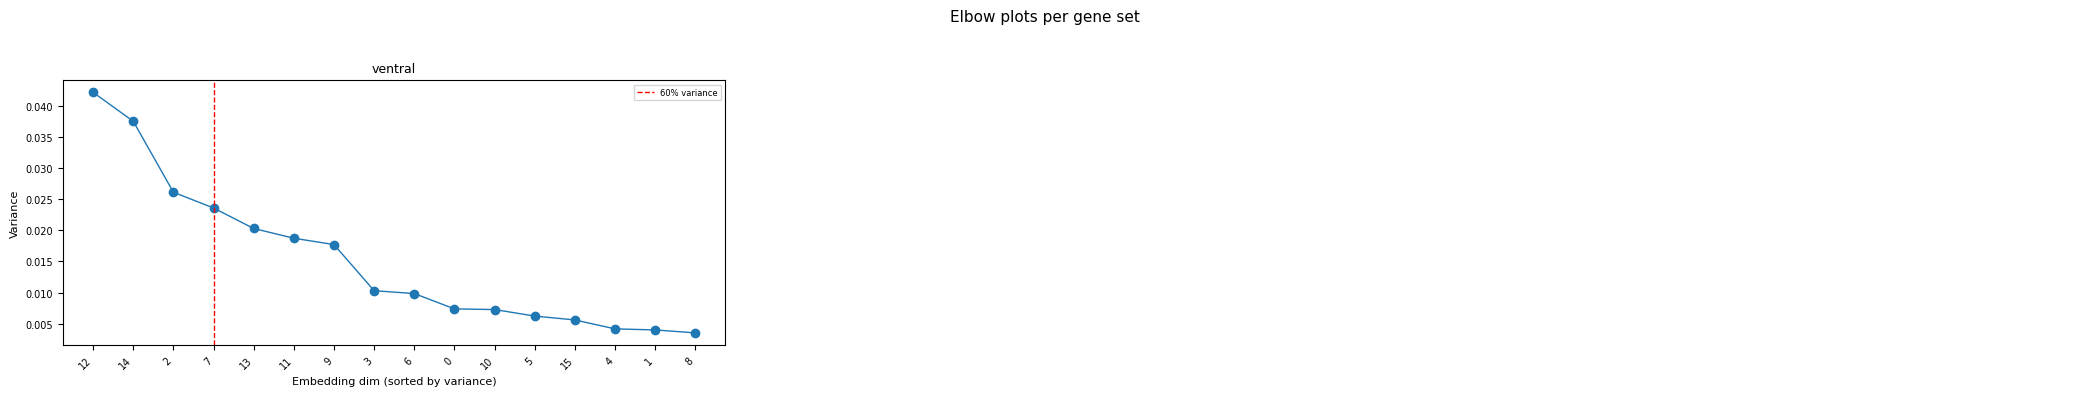

In [21]:
local_cov_df = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_local_std_gene_loadings', plot = ["ventral"])

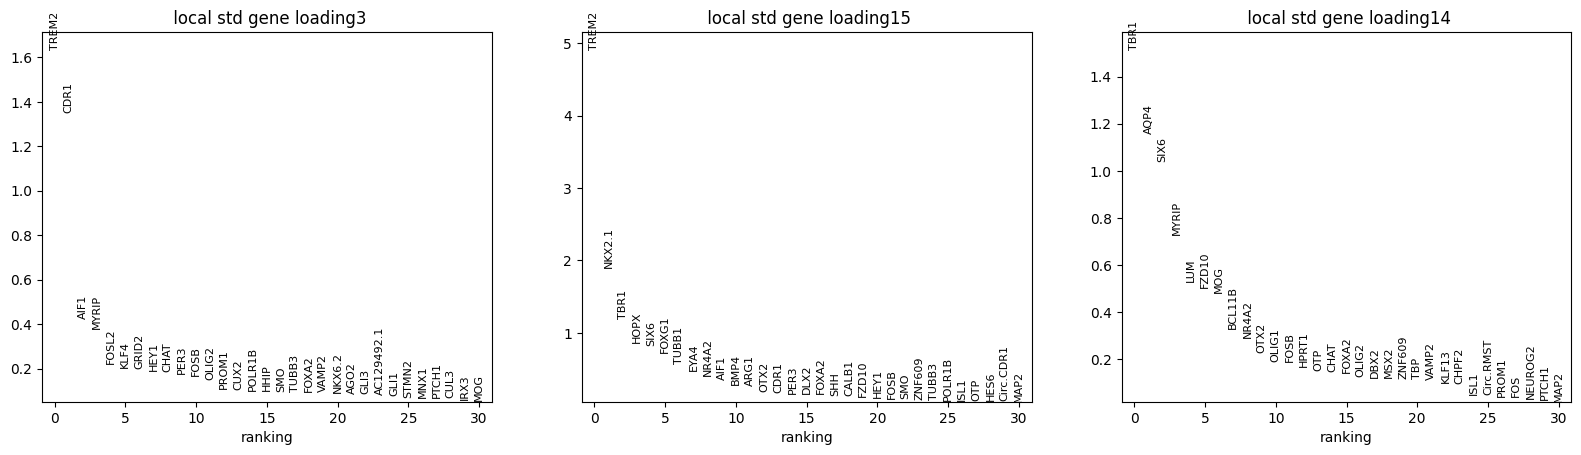

In [22]:
sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_local_std_gene_loadings',
    indices=[2,14,13],
)

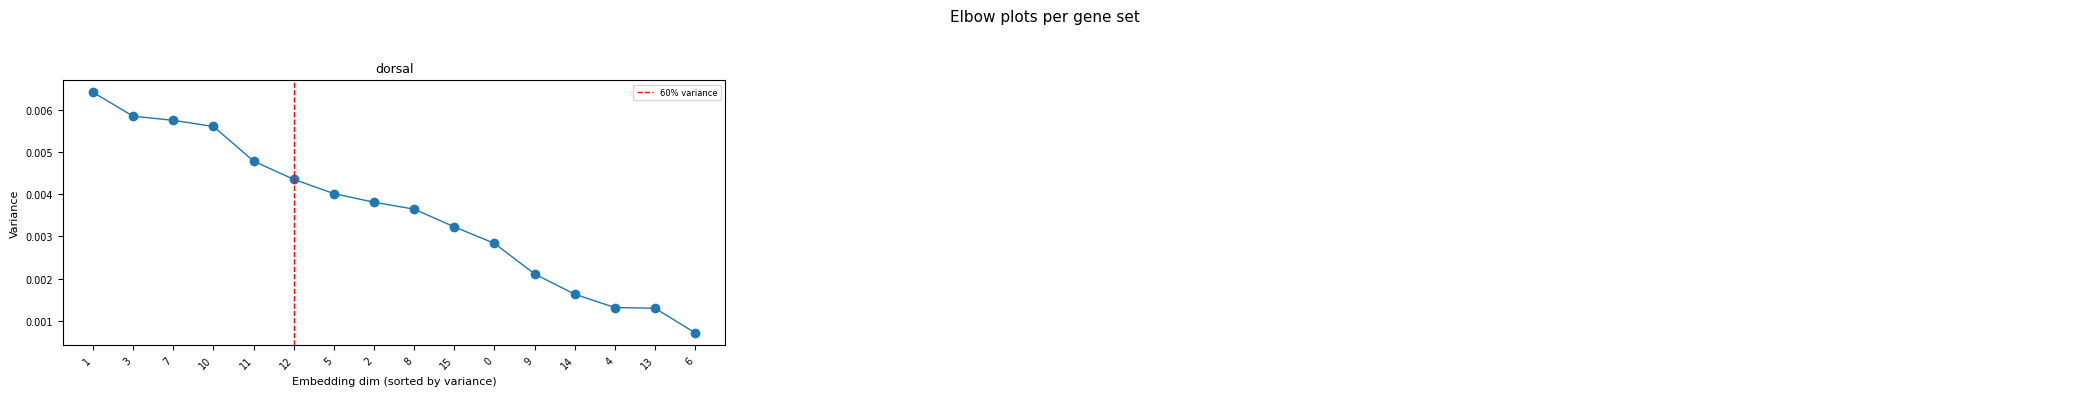

In [23]:
global_cov_df = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_global_std_gene_loadings', plot = ["dorsal"])

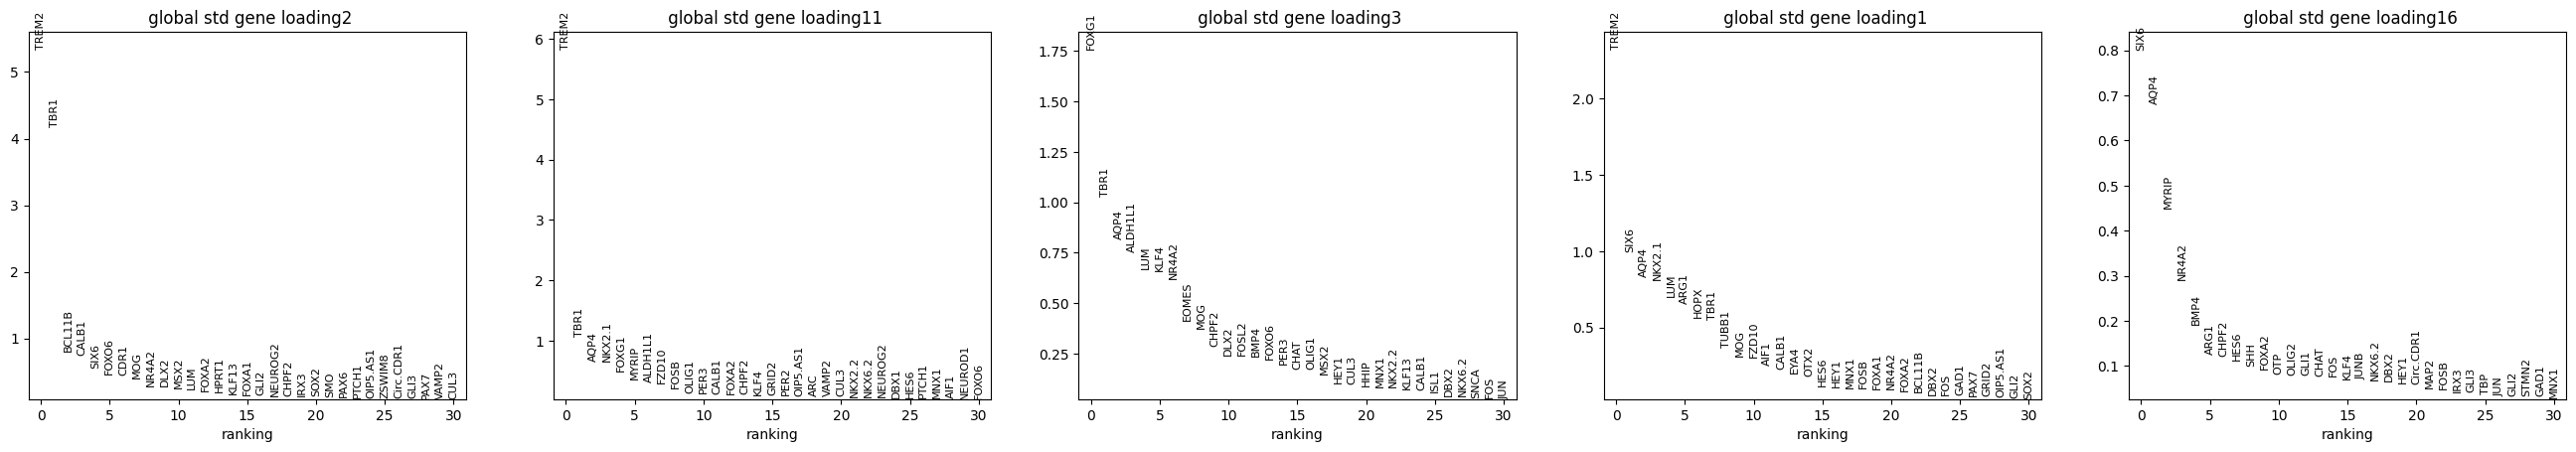

In [24]:
sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_global_std_gene_loadings',
    indices=[1,10,2,0,15],
)

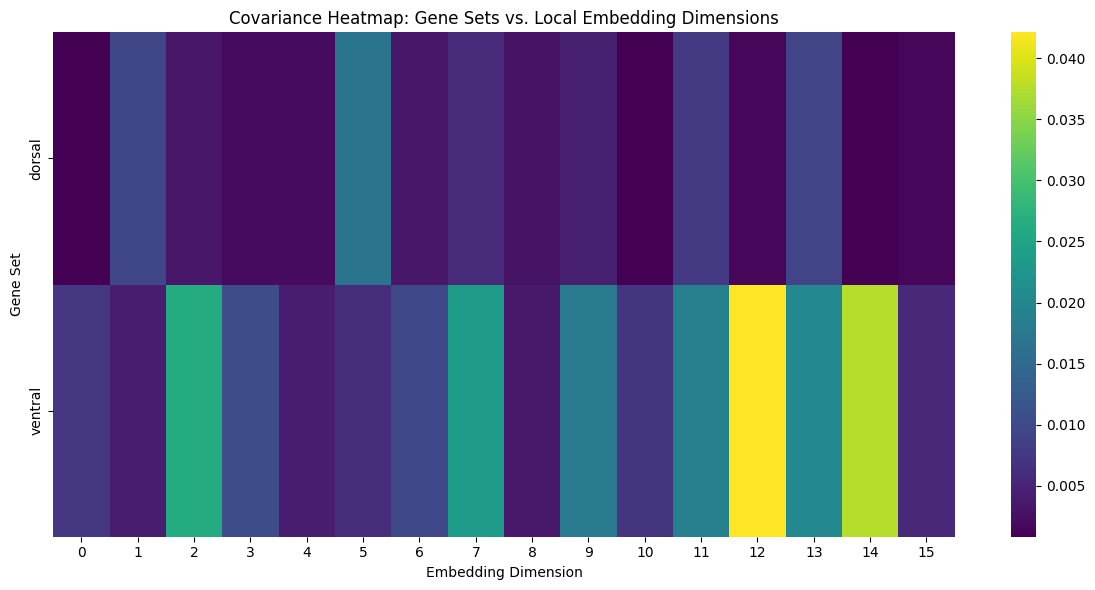

In [25]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = local_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

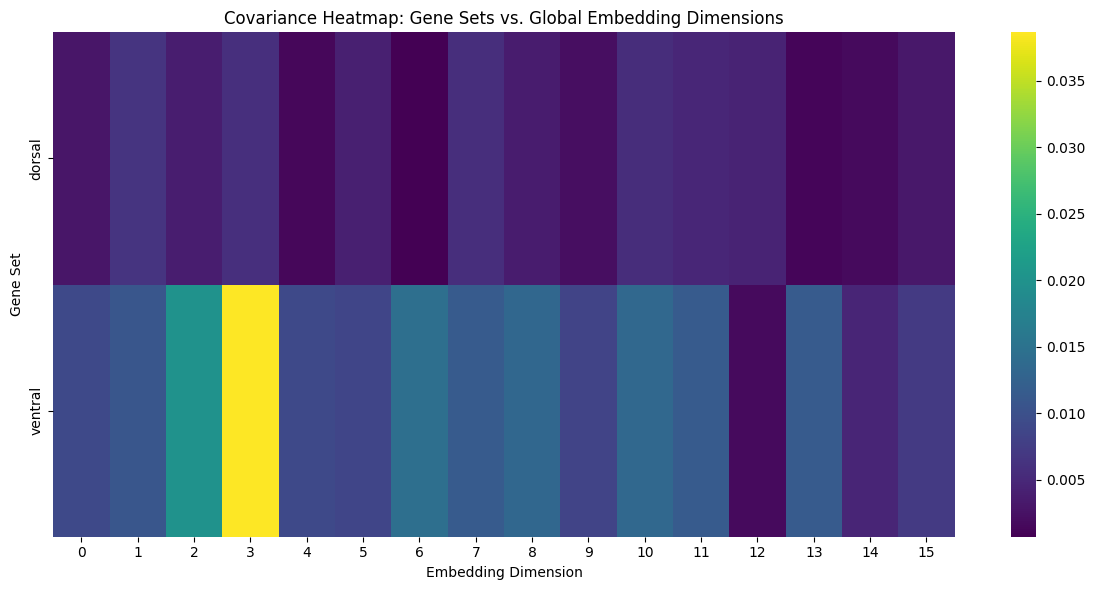

In [26]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = global_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [27]:
from InterScale.evaluation import spatial_covariance_plot

/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/_gene_set_covariance.py:226: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_key] = local_or_global_emb.iloc[:, dim_to_plot].values


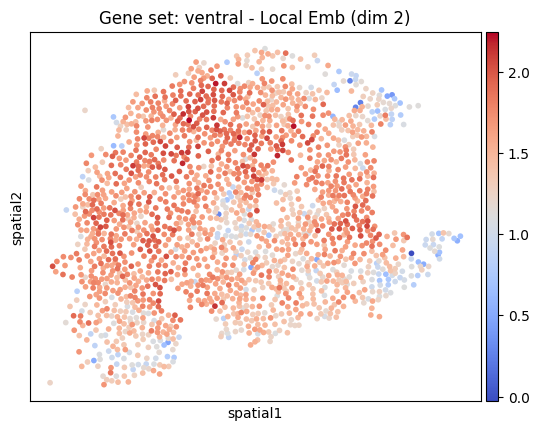

{'ventral': 2}

In [28]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "local",   # "local" or "global", 
    restrict_to = "ventral",
    emb_dim = 2, 
    cmap = "coolwarm"
)

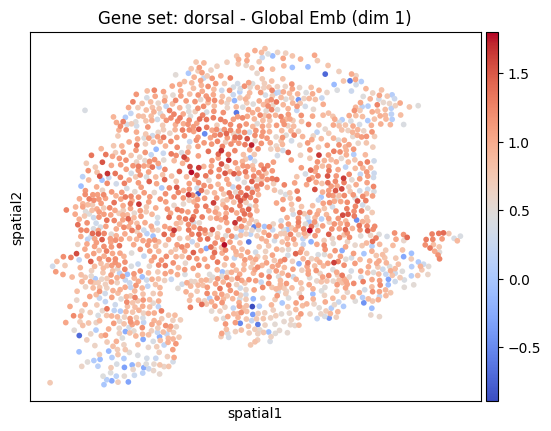

{'dorsal': 1}

In [29]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "global",   # "local" or "global", 
    restrict_to = "dorsal",
    emb_dim = 1, 
    cmap = "coolwarm"
)

#### Covariance analysis of embedding dimensions based on gene loadings

In [30]:
#1 Core: covariance-aware total explained variance

def covariance_aware_total_variance(S, Z, eps=1e-12):
    """
    S: (G, K) standardized loadings
    Z: (N, K) embedding
    Returns: total_variance, Sigma (K,K), per_gene_variance (G,)
    """
    S = np.asarray(S, dtype=np.float64)
    Z = np.asarray(Z, dtype=np.float64)

    ok = np.isfinite(Z).all(axis=1)
    Z = Z[ok]
    Zc = Z - Z.mean(axis=0, keepdims=True)

    Sigma = (Zc.T @ Zc) / max(Zc.shape[0] - 1, 1)  # Cov(Z)

    # per-gene variance: v_g = s_g^T Sigma s_g
    per_gene = np.einsum("gk,kl,gl->g", S, Sigma, S)

    total = float(per_gene.sum())
    return total, Sigma, per_gene


In [31]:
#2 Dimension importance in original basis: Shapley (accounts for correlation)

def shapley_dim_importance_total(S, Z, n_perms=200, seed=0, eps=1e-12):
    """
    Approximate Shapley importance per original latent dim for:
        V_total(subset) = trace(S_sub^T S_sub * Cov(Z_sub))
    using random permutations.

    Returns:
      importance (K,), importance_ratio (K,), total
    """
    rng = np.random.default_rng(seed)
    S = np.asarray(S, dtype=np.float64)  # (G, K)
    Z = np.asarray(Z, dtype=np.float64)  # (N, K)

    ok = np.isfinite(Z).all(axis=1)
    Z = Z[ok]
    Zc = Z - Z.mean(axis=0, keepdims=True)

    K = S.shape[1]
    imp = np.zeros(K, dtype=np.float64)

    # Precompute full matrices for fast subset eval
    Sigma_full = (Zc.T @ Zc) / max(Zc.shape[0] - 1, 1)  # (K,K)
    StS_full = S.T @ S                                  # (K,K)

    def V_of_subset(idx):
        # V = trace(StS_sub @ Sigma_sub)
        StS = StS_full[np.ix_(idx, idx)]
        Sig = Sigma_full[np.ix_(idx, idx)]
        return float(np.trace(StS @ Sig))

    for _ in range(n_perms):
        perm = rng.permutation(K)
        included = []
        prev = 0.0
        for k in perm:
            included.append(k)
            cur = V_of_subset(included)
            imp[k] += (cur - prev)
            prev = cur

    imp /= n_perms
    total = float(imp.sum())
    ratio = imp / total if total > eps else np.zeros_like(imp)
    return imp, ratio, total


In [32]:
#3 Gene ranking per original dimension that accounts for correlation: residualized effect

def residualized_gene_ranking(S, Z, var_names, n_top=50, eps=1e-12):
    """
    For each dim k:
      - residualize z_k against other dims
      - score gene g by |S_gk| * std(residual(z_k))
    Returns:
      top_genes[k], top_scores[k], resid_std[k]
    """
    S = np.asarray(S, dtype=np.float64)      # (G,K)
    Z = np.asarray(Z, dtype=np.float64)      # (N,K)
    var_names = np.asarray(var_names)

    ok = np.isfinite(Z).all(axis=1)
    Z = Z[ok]
    Zc = Z - Z.mean(axis=0, keepdims=True)

    N, K = Zc.shape
    top_genes = []
    top_scores = []
    resid_std = np.zeros(K, dtype=np.float64)

    # Precompute for speed: add intercept by centering Zc (already centered)
    for k in range(K):
        y = Zc[:, k]
        X = np.delete(Zc, k, axis=1)  # (N, K-1)

        if X.shape[1] == 0:
            r = y
        else:
            # Solve least squares: minimize ||X b - y||
            b, *_ = np.linalg.lstsq(X, y, rcond=None)
            r = y - X @ b

        sd = float(np.std(r, ddof=1))
        if not np.isfinite(sd) or sd < eps:
            sd = eps
        resid_std[k] = sd

        scores = np.abs(S[:, k]) * sd
        idx = np.argsort(-scores)[:n_top]
        top_genes.append(var_names[idx].tolist())
        top_scores.append(scores[idx].tolist())

    return top_genes, top_scores, resid_std


In [33]:
def decoder_interpretability_workflow(
    adata,
    local_S_key="_local_std_gene_loadings",
    global_S_key="_global_std_gene_loadings",
    local_Z_key="_local_emb",
    global_Z_key="_global_emb",
    n_perms=200,
    n_top_genes=50,
    seed=0,
    uns_key="decoder_importance",
):
    out = {}

    for name, S_key, Z_key in [
        ("local", local_S_key, local_Z_key),
        ("global", global_S_key, global_Z_key),
    ]:
        S = adata.varm[S_key]
        Z = adata.obsm[Z_key]

        total, Sigma, per_gene = covariance_aware_total_variance(S, Z)
        imp, imp_ratio, total_check = shapley_dim_importance_total(
            S, Z, n_perms=n_perms, seed=seed
        )

        top_genes, top_scores, resid_std = residualized_gene_ranking(
            S, Z, adata.var_names, n_top=n_top_genes
        )

        out[name] = {
            # covariance-aware variance
            "total_variance": total,
            "per_gene_variance": per_gene,          # length G
            "cov_latent": Sigma,                    # (K,K) can be large; store if you want

            # Shapley dimension importance (original basis)
            "dim_importance": imp,                  # length K
            "dim_importance_ratio": imp_ratio,      # length K

            # gene lists per original dimension using residualized latent
            "resid_std_per_dim": resid_std,         # length K
            "top_genes_per_dim": top_genes,         # list[K] of gene names
            "top_gene_scores_per_dim": top_scores,  # list[K] of scores
        }

    adata.uns[uns_key] = out
    return adata

In [34]:
decoder_interpretability_workflow(ctrl_test)

AnnData object with n_obs × n_vars = 1772 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical', 'ventral_local', 'dorsal_global'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'decoder_importance'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [35]:
ctrl_test.uns['decoder_importance']['local'].keys()

dict_keys(['total_variance', 'per_gene_variance', 'cov_latent', 'dim_importance', 'dim_importance_ratio', 'resid_std_per_dim', 'top_genes_per_dim', 'top_gene_scores_per_dim'])

In [36]:
# -----------------------------
# Internal utilities (minimal)
# -----------------------------
def _get_Z(adata, z_key):
    if z_key not in adata.obsm:
        raise KeyError(f"{z_key} not found in adata.obsm")
    Z = np.asarray(adata.obsm[z_key], dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    ok = np.isfinite(Z).all(axis=1)
    if ok.sum() == 0:
        raise ValueError(f"No finite rows in adata.obsm['{z_key}']")
    return Z[ok]

def _get_S(adata, s_key):
    if s_key not in adata.varm:
        raise KeyError(f"{s_key} not found in adata.varm")
    S = np.asarray(adata.varm[s_key], dtype=float)
    if S.ndim != 2:
        raise ValueError(f"adata.varm['{s_key}'] must be 2D (n_genes, n_latent)")
    return S

def _cov(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    return (Zc.T @ Zc) / max(Zc.shape[0] - 1, 1)

def _corr(Z, eps=1e-12):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    sd = Zc.std(axis=0, ddof=1, keepdims=True)
    sd[sd < eps] = eps
    Zs = Zc / sd
    return (Zs.T @ Zs) / max(Zs.shape[0] - 1, 1)

def _naive_ratio(S, eps=1e-12):
    v = np.sum(S * S, axis=0)
    tot = v.sum()
    return v / tot if tot > eps else np.zeros_like(v)

def _shapley_importance_ratio(S, Z, n_perms=200, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    S = np.asarray(S, dtype=float)
    Z = np.asarray(Z, dtype=float)

    Sigma_full = _cov(Z)
    StS_full = S.T @ S
    K = S.shape[1]

    def V(idx):
        StS = StS_full[np.ix_(idx, idx)]
        Sig = Sigma_full[np.ix_(idx, idx)]
        return float(np.trace(StS @ Sig))

    imp = np.zeros(K, dtype=float)
    for _ in range(n_perms):
        perm = rng.permutation(K)
        included = []
        prev = 0.0
        for k in perm:
            included.append(k)
            cur = V(included)
            imp[k] += (cur - prev)
            prev = cur

    imp /= n_perms
    tot = imp.sum()
    return imp / tot if tot > eps else np.zeros_like(imp)

def _resid_std_per_dim(Z, eps=1e-12):
    Z = np.asarray(Z, dtype=float)
    Zc = Z - Z.mean(axis=0, keepdims=True)
    N, K = Zc.shape
    resid_std = np.zeros(K, dtype=float)

    for k in range(K):
        y = Zc[:, k]
        X = np.delete(Zc, k, axis=1)
        if X.shape[1] == 0:
            r = y
        else:
            b, *_ = np.linalg.lstsq(X, y, rcond=None)
            r = y - X @ b
        sd = float(np.std(r, ddof=1))
        resid_std[k] = sd if np.isfinite(sd) and sd > eps else eps

    return resid_std


# -----------------------------
# Scanpy-style plotting functions
# -----------------------------
def pl_latent_correlation(
    adata,
    z_key="_global_emb",
    vmax=1.0,
    cmap="coolwarm",
    figsize=(6, 5),
    title=None,
    show=True,
):
    """
    Heatmap of Corr(Z) for embedding dimensions.

    Parameters
    ----------
    adata : AnnData
    z_key : str
        adata.obsm key for embeddings
    """
    Z = _get_Z(adata, z_key)
    C = _corr(Z)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(C, vmin=-vmax, vmax=vmax, cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel("latent dim")
    ax.set_ylabel("latent dim")
    ax.set_title(title or f"Correlation of {z_key}")
    plt.tight_layout()
    if show:
        plt.show()
    return ax


def pl_latent_cov_spectrum(
    adata,
    z_key="_local_emb",
    logy=True,
    figsize=(6, 4),
    title=None,
    show=True,
    marker="o",
    label_fontsize=9,
    label_offset=(0, 5),  # (dx, dy) in points
):
    """
    Parameters
    ----------
    adata : AnnData
    z_key : str
        adata.obsm key for embeddings
    logy : bool
        log-scale on y-axis
    label_offset : (int, int)
        text offset in points for dimension labels
    """
    Z = _get_Z(adata, z_key)
    Sigma = _cov(Z)

    # eigenvalues (ascending), then sort descending
    evals = np.linalg.eigvalsh(Sigma)
    evals = np.maximum(evals, 0.0)
    order = np.argsort(evals)[::-1]

    evals = evals[order]      # sorted eigenvalues (descending)
    dim_ids = order           # original embedding dimension indices
    ranks = np.arange(len(evals))

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(ranks, evals, "-", lw=1)
    ax.scatter(ranks, evals, s=25, marker=marker)

    # annotate each rank with original dim id
    for r, y, k in zip(ranks, evals, dim_ids):
        ax.annotate(
            str(int(k)),
            (r, y),
            textcoords="offset points",
            xytext=label_offset,
            ha="center",
            fontsize=label_fontsize,
        )

    if logy:
        ax.set_yscale("log")

    ax.set_xlabel("rank (by covariance eigenvalue)")
    ax.set_ylabel("eigenvalue of Cov(Z)")
    ax.set_title(title or f"Cov spectrum of {z_key}")

    plt.tight_layout()
    if show:
        plt.show()

    return ax
    
def pl_dim_importance_naive_vs_shapley(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    n_perms=200,
    seed=0,
    figsize=(7, 4),
    title=None,
    show=True,
):
    """
    Compare naive per-dim importance (sum_g S^2) vs Shapley importance (cov-aware),
    both normalized to sum to 1.

    Parameters
    ----------
    adata : AnnData
    s_key : str
        adata.varm key for standardized gene loadings
    z_key : str
        adata.obsm key for embeddings
    """
    S = _get_S(adata, s_key)
    Z = _get_Z(adata, z_key)

    naive = _naive_ratio(S)
    shap = _shapley_importance_ratio(S, Z, n_perms=n_perms, seed=seed)

    x = np.arange(S.shape[1])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(x, naive, "o-", label="naive (sum S^2)")
    ax.plot(x, shap, "o-", label="Shapley (cov-aware)")
    ax.set_xlabel("latent dimension")
    ax.set_ylabel("importance ratio")
    ax.set_title(title or f"Dim importance: {s_key} + {z_key}")
    ax.legend()
    plt.tight_layout()
    if show:
        plt.show()
    return ax

def pl_dim_importance_stability(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    n_reps=10,
    subsample_frac=0.8,
    n_perms=150,
    seed=0,
    figsize=(6, 4),
    title=None,
    show=True,
):
    """
    Bootstrap-style stability plot for Shapley importance ratio over cell subsamples.

    Shows mean +/- std across repetitions for each latent dimension.
    """
    S = _get_S(adata, s_key)
    Z_full = np.asarray(adata.obsm[z_key], dtype=float)
    if Z_full.ndim == 1:
        Z_full = Z_full[:, None]

    ok = np.isfinite(Z_full).all(axis=1)
    Z_full = Z_full[ok]

    rng = np.random.default_rng(seed)
    N = Z_full.shape[0]
    m = max(2, int(subsample_frac * N))

    ratios = []
    for r in range(n_reps):
        idx = rng.choice(N, size=m, replace=False)
        Z = Z_full[idx]
        ratios.append(_shapley_importance_ratio(S, Z, n_perms=n_perms, seed=seed + r))

    ratios = np.asarray(ratios)
    mean = ratios.mean(axis=0)
    std = ratios.std(axis=0)

    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(np.arange(len(mean)), mean, yerr=std, fmt="o", capsize=3)
    ax.set_xlabel("latent dimension")
    ax.set_ylabel("Shapley importance ratio")
    ax.set_title(title or f"Stability: {s_key} + {z_key}")
    plt.tight_layout()
    if show:
        plt.show()
    return ax

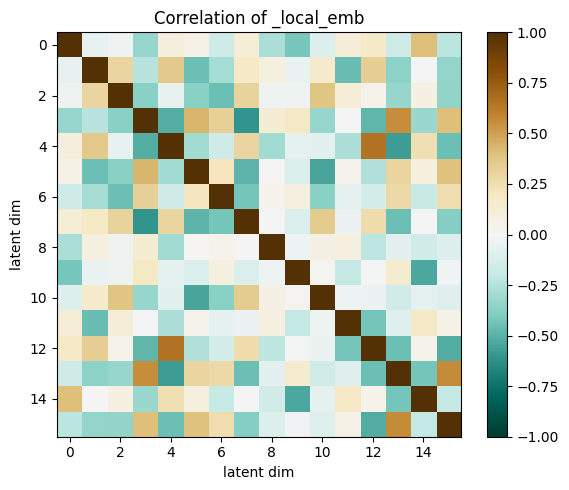

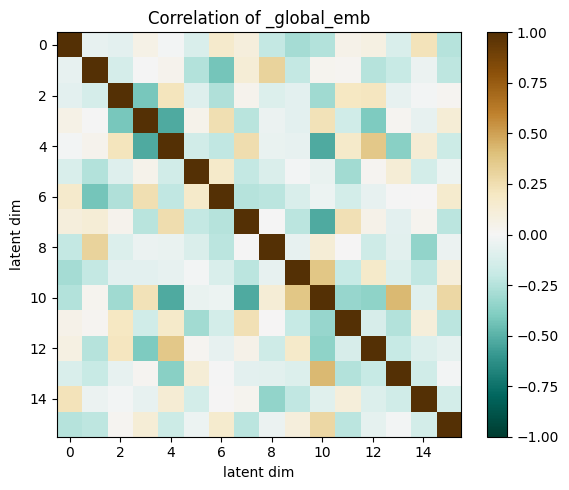

<Axes: title={'center': 'Correlation of _global_emb'}, xlabel='latent dim', ylabel='latent dim'>

In [37]:
# Are the latent dimensions correlated?

pl_latent_correlation(ctrl_test, z_key="_local_emb", vmax=1.0, cmap="BrBG_r")
pl_latent_correlation(ctrl_test, z_key="_global_emb", vmax=1.0, cmap="BrBG_r")

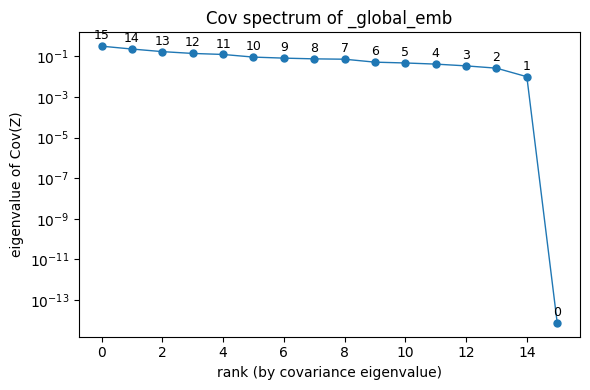

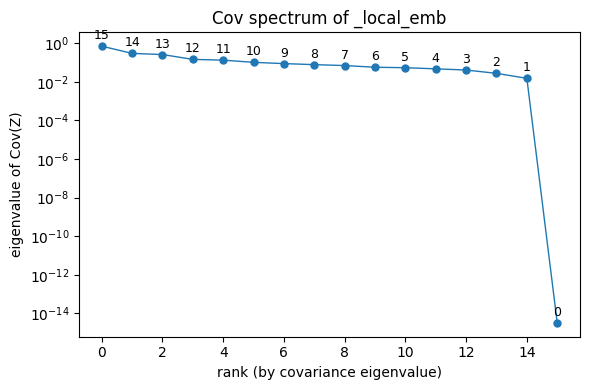

<Axes: title={'center': 'Cov spectrum of _local_emb'}, xlabel='rank (by covariance eigenvalue)', ylabel='eigenvalue of Cov(Z)'>

In [38]:
# How many effective degrees of freedom are there?

# i.e., if “16 dims” really means 16 independent signals

pl_latent_cov_spectrum(ctrl_test, z_key="_global_emb")
pl_latent_cov_spectrum(ctrl_test, z_key="_local_emb")

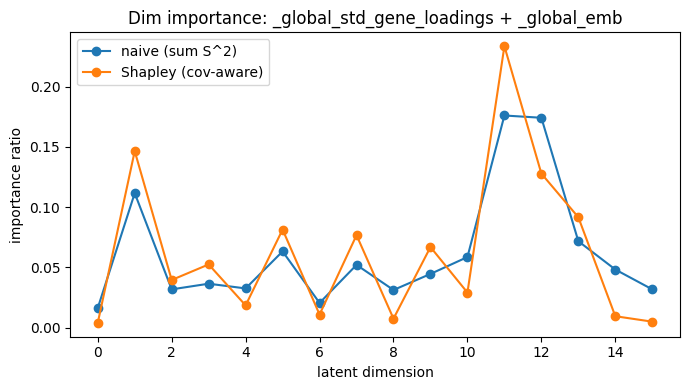

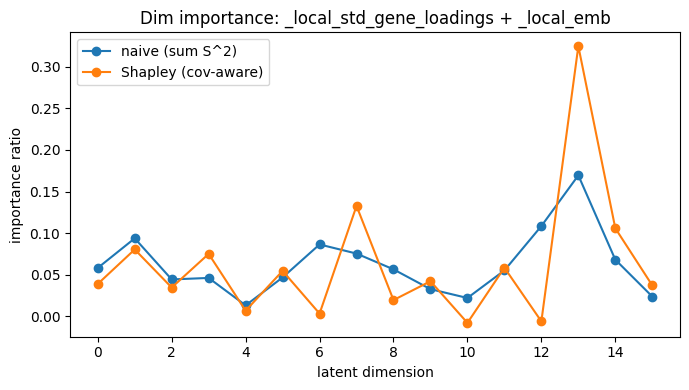

<Axes: title={'center': 'Dim importance: _local_std_gene_loadings + _local_emb'}, xlabel='latent dimension', ylabel='importance ratio'>

In [39]:
#3 Compare naive vs Shapley dimension importance
# Which dims look important only because of correlation?

pl_dim_importance_naive_vs_shapley(ctrl_test, s_key="_global_std_gene_loadings", z_key="_global_emb")
pl_dim_importance_naive_vs_shapley(ctrl_test, s_key="_local_std_gene_loadings", z_key="_local_emb")

Naive: If dimension k were acting alone, how much signal does it carry into genes?
Shapley importance=the average increase in explained variance when dimension k is added to a model that already has some other dimensions.

- independent dimensions: Shapley ≈ naive
- Ratio: What fraction of the decoder’s total covariance-aware explained variance is attributable to dimension k?

In [40]:
import numpy as np
import matplotlib.pyplot as plt


def pl_shapley_dim_importance_elbow(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    n_perms=200,
    seed=0,
    use_ratio=True,              # True -> plot importance_ratio (sums to 1), False -> plot raw Shapley
    variance_cutoff=0.90,        # cumulative cutoff (only used if use_ratio=True)
    ncols=1,                     # keep for future grid-compat; currently single plot
    fontsize=12,
    figsize=(8, 4.5),
    spacing=2,                   # spacing between dots like your example
    title=None,
    show=True,
):
    """
    Elbow plot of Shapley dimension importance, with dims sorted by Shapley.

    - Computes Shapley importance for each latent dim (covariance-aware).
    - Sorts dims descending (most important on the left).
    - Plots only Shapley on y-axis.
    - X ticks are original embedding dimension indices (sorted by Shapley).

    Parameters
    ----------
    adata : AnnData
    s_key : str
        adata.varm key for standardized gene loadings (G, K)
    z_key : str
        adata.obsm key for embeddings (N, K)
    n_perms : int
        number of random permutations to approximate Shapley
    use_ratio : bool
        if True, plot normalized Shapley importance_ratio (sums to 1)
        if False, plot raw Shapley values
    variance_cutoff : float
        if use_ratio=True, draw a vertical line at the smallest number of dims
        whose cumulative importance >= variance_cutoff
    """

    # ----- basic checks / load
    if s_key not in adata.varm:
        raise KeyError(f"{s_key} not found in adata.varm")
    if z_key not in adata.obsm:
        raise KeyError(f"{z_key} not found in adata.obsm")

    S = np.asarray(adata.varm[s_key], dtype=float)
    Z = np.asarray(adata.obsm[z_key], dtype=float)
    if Z.ndim == 1:
        Z = Z[:, None]
    if S.ndim != 2:
        raise ValueError(f"adata.varm['{s_key}'] must be 2D (n_genes, n_latent)")
    if S.shape[1] != Z.shape[1]:
        raise ValueError(f"Latent dim mismatch: S has {S.shape[1]}, Z has {Z.shape[1]}")

    # ----- compute Shapley (minimal inline implementation)
    rng = np.random.default_rng(seed)

    ok = np.isfinite(Z).all(axis=1)
    if ok.sum() == 0:
        raise ValueError(f"No finite rows in adata.obsm['{z_key}']")
    Z = Z[ok]
    Zc = Z - Z.mean(axis=0, keepdims=True)

    Sigma_full = (Zc.T @ Zc) / max(Zc.shape[0] - 1, 1)  # Cov(Z)
    StS_full = S.T @ S                                  # S^T S
    K = S.shape[1]

    def V(idx):
        StS = StS_full[np.ix_(idx, idx)]
        Sig = Sigma_full[np.ix_(idx, idx)]
        return float(np.trace(StS @ Sig))

    shap = np.zeros(K, dtype=float)
    for r in range(n_perms):
        perm = rng.permutation(K)
        included = []
        prev = 0.0
        for k in perm:
            included.append(k)
            cur = V(included)
            shap[k] += (cur - prev)
            prev = cur
    shap /= max(n_perms, 1)

    # ----- choose y values
    if use_ratio:
        total = shap.sum()
        y = shap / total if total > 0 else np.zeros_like(shap)
        ylab = "Shapley importance ratio"
    else:
        y = shap
        ylab = "Shapley importance"

    # ----- sort dims by Shapley descending
    order = np.argsort(y)[::-1]
    y_sorted = y[order]
    dim_sorted = order  # original dimension indices

    # ----- x positions with spacing like your example
    x = np.arange(K) * spacing

    # ----- cutoff position (only meaningful for ratios)
    cutoff_x = None
    if use_ratio and variance_cutoff is not None:
        cum = np.cumsum(y_sorted)
        cutoff_dim = int(np.searchsorted(cum, variance_cutoff, side="left"))
        cutoff_x = cutoff_dim * spacing

    # ----- plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(x, y_sorted, marker="o", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(dim_sorted.astype(str), rotation=45, ha="right", fontsize=fontsize - 1)

    if cutoff_x is not None:
        ax.axvline(
            x=cutoff_x,
            linestyle="--",
            linewidth=1,
            color="red",
            label=f"{int(variance_cutoff * 100)}% cumulative"
        )
        ax.legend(fontsize=fontsize - 2, loc="best")

    ax.set_title(title or f"Shapley elbow: {s_key} + {z_key}", fontsize=fontsize + 1)
    ax.set_xlabel("Embedding dim (sorted by Shapley)", fontsize=fontsize)
    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.tick_params(axis="both", labelsize=fontsize - 1)
    ax.grid(False)

    plt.tight_layout()
    if show:
        plt.show()

    return ax

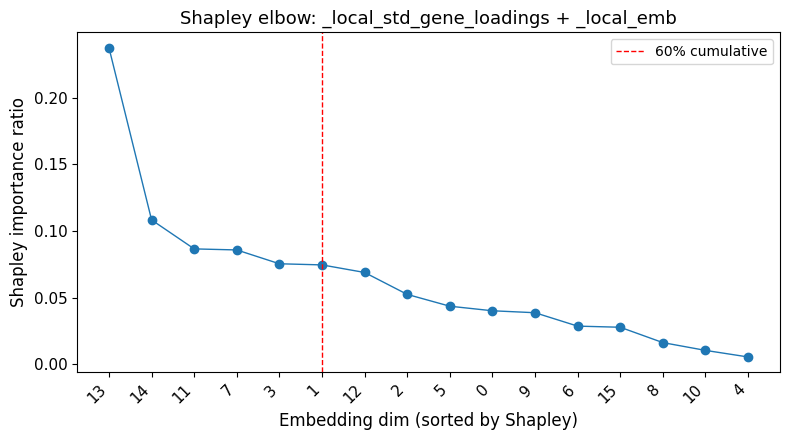

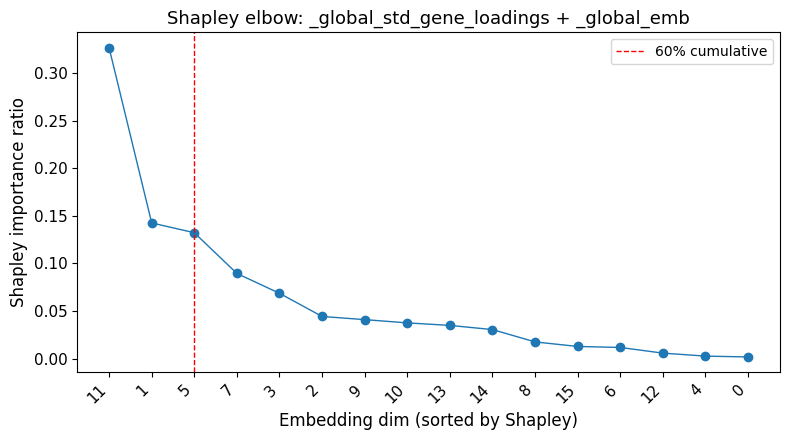

<Axes: title={'center': 'Shapley elbow: _global_std_gene_loadings + _global_emb'}, xlabel='Embedding dim (sorted by Shapley)', ylabel='Shapley importance ratio'>

In [41]:
# Local
pl_shapley_dim_importance_elbow(
    adata,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    n_perms=200,
    variance_cutoff=0.6,
    use_ratio=True,
)

# Global
pl_shapley_dim_importance_elbow(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    n_perms=200,
    variance_cutoff=0.6,
    use_ratio=True,
)



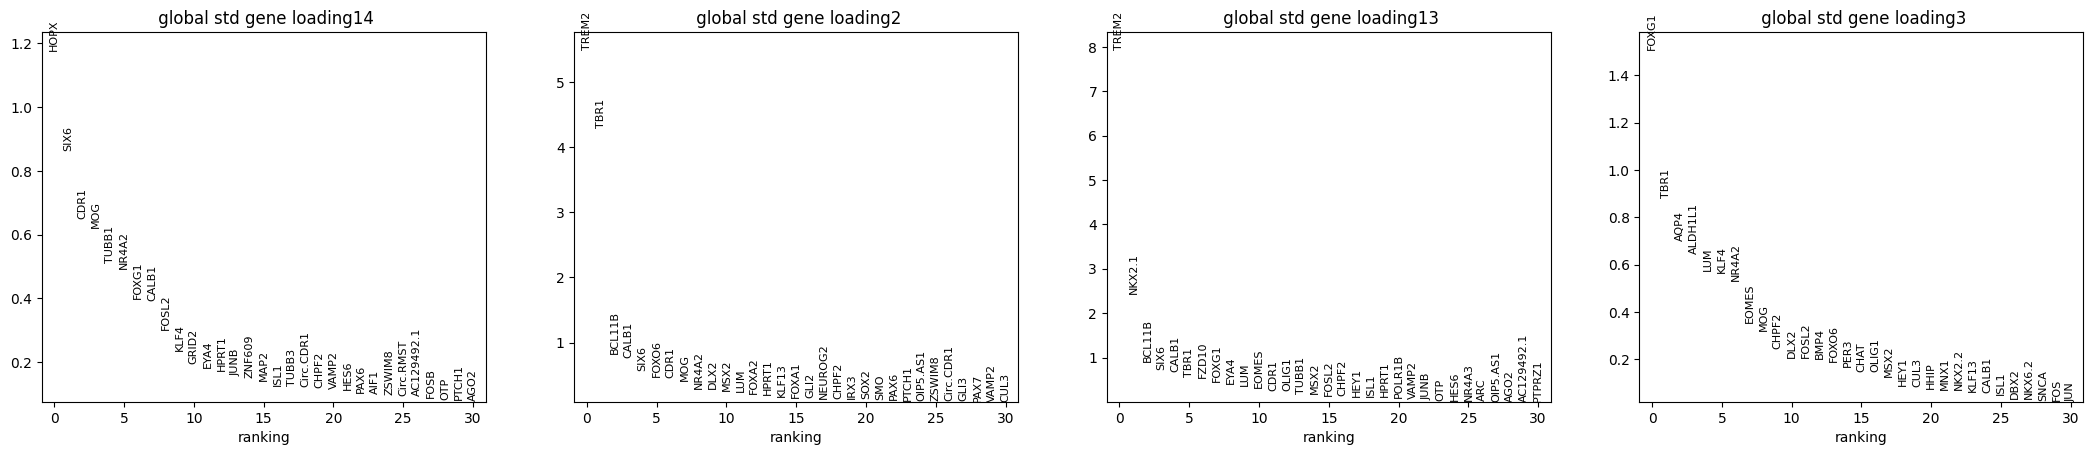

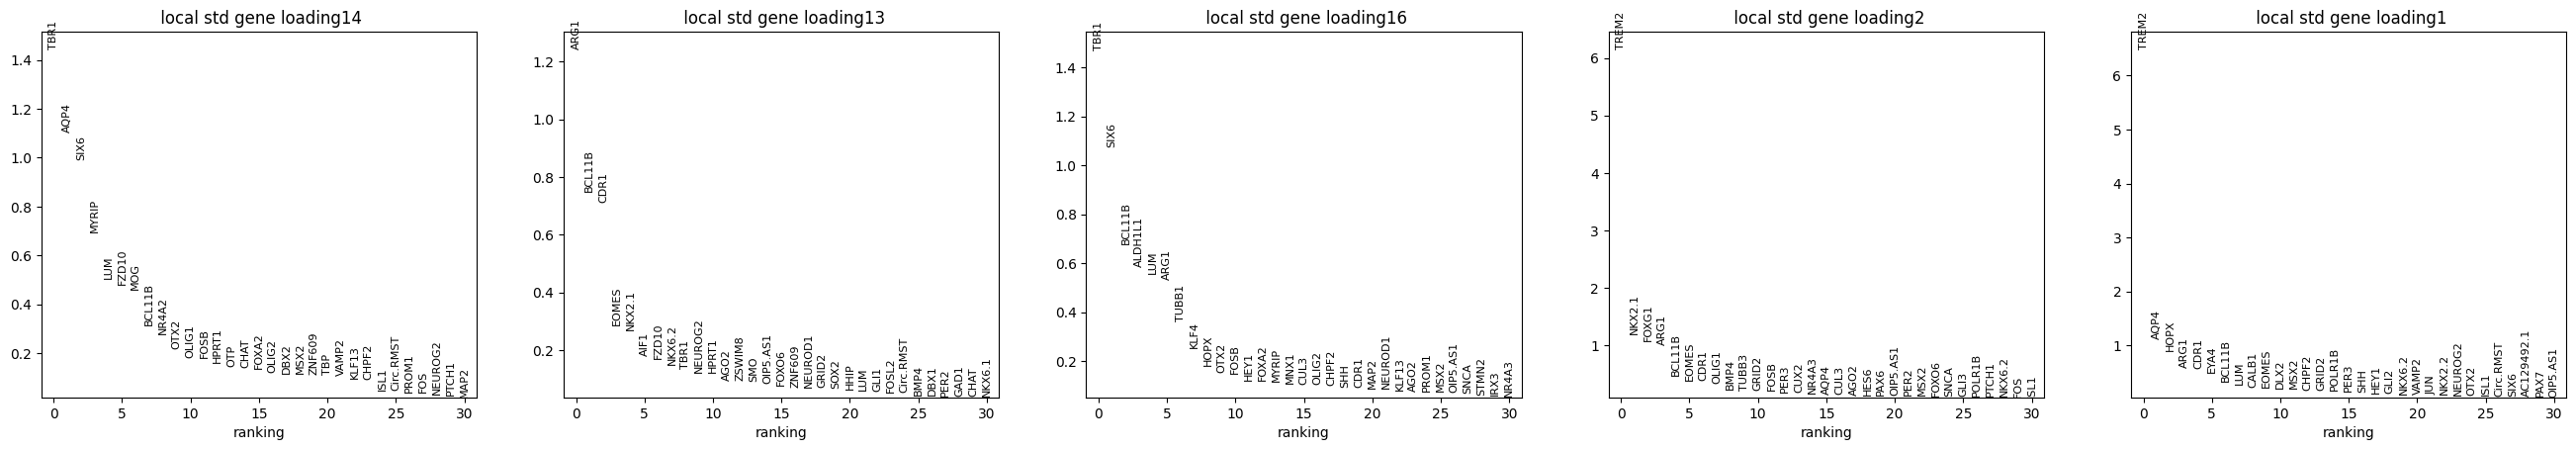

In [40]:
#4 Gene-level interpretability

sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_local_std_gene_loadings'
    indices=[13,14,11,7,3,1],
)

sc.pl.ranking(
    ctrl_test, 
    attr='varm',
    keys='_global_std_gene_loadings',
    indices=[11,1,5],
)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def pl_gene_signed_contribution_bar(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    dim=0,
    n_top=30,
    score_mode="residualized",  # "residualized" (recommended) or "naive"
    figsize=(5.5, 6),
    title=None,
    show=True,
):
    if s_key not in adata.varm:
        raise KeyError(f"{s_key} not found in adata.varm")
    if z_key not in adata.obsm:
        raise KeyError(f"{z_key} not found in adata.obsm")

    S = np.asarray(adata.varm[s_key], dtype=float)
    Z = np.asarray(adata.obsm[z_key], dtype=float)
    var_names = np.asarray(adata.var_names)

    if Z.ndim == 1:
        Z = Z[:, None]
    if dim < 0 or dim >= S.shape[1]:
        raise ValueError(f"dim must be in [0, {S.shape[1]-1}]")

    # ----- compute scores
    if score_mode == "residualized":
        ok = np.isfinite(Z).all(axis=1)
        Z = Z[ok]
        Zc = Z - Z.mean(axis=0, keepdims=True)

        y = Zc[:, dim]
        X = np.delete(Zc, dim, axis=1)

        if X.shape[1] > 0:
            b, *_ = np.linalg.lstsq(X, y, rcond=None)
            r = y - X @ b
        else:
            r = y

        resid_std = np.std(r, ddof=1)
        resid_std = resid_std if np.isfinite(resid_std) and resid_std > 0 else 0.0
        score = S[:, dim] * resid_std
        xlab = "signed residualized contribution"
    else:
        score = S[:, dim]
        xlab = "signed standardized loading (naive)"

    # ----- select and order genes
    idx = np.argsort(-np.abs(score))[:n_top]
    score_top = score[idx]
    genes_top = var_names[idx]

    order = np.argsort(score_top)
    score_top = score_top[order]
    genes_top = genes_top[order]

    # ----- color mapping (THIS IS THE NEW PART)
    vmax = np.max(np.abs(score_top))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    cmap = plt.cm.BrBG_r
    colors = cmap(norm(score_top))

    # ----- plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(np.arange(len(score_top)), score_top, color=colors)
    ax.axvline(0, lw=1, color="black")

    ax.set_yticks(np.arange(len(score_top)))
    ax.set_yticklabels(genes_top)
    ax.set_xlabel(xlab)
    ax.set_title(title or f"{s_key} | dim={dim} ({score_mode})")

    # optional colorbar (very helpful)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046)
    cbar.set_label("signed contribution")

    plt.tight_layout()
    if show:
        plt.show()

    return ax


def pl_gene_dim_heatmap(
    adata,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    dims=None,               # e.g. [0,1,2,3] or None -> auto top by Shapley
    n_top_dims=10,           # used if dims is None
    n_top_genes_per_dim=20,  # union of top genes per dim
    gene_score_mode="residualized",  # "residualized" or "naive"
    dim_score_mode="shapley",        # "shapley" or "naive" (used only if dims is None)
    n_perms=150,             # shapley perms (only if dim_score_mode="shapley" and dims is None)
    seed=0,
    cluster_genes=False,     # optional lightweight clustering for rows
    figsize=(8, 6),
    cmap="BrBG_r",
    vcenter=0.0,
    show=True,
    title=None,
):
    """
    Heatmap across dims for a UNION of top genes, using signed scores.

    What you see:
      - rows: genes (union of top genes from selected dims)
      - cols: selected dims
      - values: signed scores per gene x dim

    Scores:
      - if gene_score_mode="residualized":
            score[g,k] = S[g,k] * std(residual(z_k ~ Z_-k))
        This accounts for correlation in the embedding by downweighting
        dimensions whose variation is explained by others.
      - if gene_score_mode="naive":
            score[g,k] = S[g,k]

    If dims is None:
      - select dims by dim_score_mode:
          * "naive":   sum_g S[g,k]^2
          * "shapley": Shapley importance (covariance-aware; slower)
    """
    if s_key not in adata.varm:
        raise KeyError(f"{s_key} not found in adata.varm")
    if z_key not in adata.obsm:
        raise KeyError(f"{z_key} not found in adata.obsm")

    S = np.asarray(adata.varm[s_key], dtype=float)  # (G, K)
    Z = np.asarray(adata.obsm[z_key], dtype=float)  # (N, K)
    genes = np.asarray(adata.var_names)

    if Z.ndim == 1:
        Z = Z[:, None]
    if S.shape[1] != Z.shape[1]:
        raise ValueError(f"Latent dim mismatch: S has {S.shape[1]}, Z has {Z.shape[1]}")

    G, K = S.shape

    # ----- choose dims if not provided
    if dims is None:
        if dim_score_mode == "naive":
            v = np.sum(S * S, axis=0)
            order = np.argsort(v)[::-1]
            dims = order[:n_top_dims].tolist()
        elif dim_score_mode == "shapley":
            # Minimal Shapley (same payoff used earlier): trace(StS_sub @ Cov_sub)
            rng = np.random.default_rng(seed)
            ok = np.isfinite(Z).all(axis=1)
            Z_use = Z[ok]
            Zc = Z_use - Z_use.mean(axis=0, keepdims=True)
            Sigma_full = (Zc.T @ Zc) / max(Zc.shape[0] - 1, 1)
            StS_full = S.T @ S

            def V(idx):
                StS = StS_full[np.ix_(idx, idx)]
                Sig = Sigma_full[np.ix_(idx, idx)]
                return float(np.trace(StS @ Sig))

            imp = np.zeros(K, dtype=float)
            for r in range(n_perms):
                perm = rng.permutation(K)
                included = []
                prev = 0.0
                for k_ in perm:
                    included.append(k_)
                    cur = V(included)
                    imp[k_] += (cur - prev)
                    prev = cur
            imp /= max(n_perms, 1)
            order = np.argsort(imp)[::-1]
            dims = order[:n_top_dims].tolist()
        else:
            raise ValueError("dim_score_mode must be 'shapley' or 'naive'")

    dims = list(dims)
    if any((d < 0 or d >= K) for d in dims):
        raise ValueError(f"dims must be within [0, {K-1}]")

    # ----- compute residual std per dim (only if needed)
    if gene_score_mode == "residualized":
        ok = np.isfinite(Z).all(axis=1)
        Z_use = Z[ok]
        Zc = Z_use - Z_use.mean(axis=0, keepdims=True)

        resid_std = np.zeros(K, dtype=float)
        for k_ in range(K):
            y = Zc[:, k_]
            X = np.delete(Zc, k_, axis=1)
            if X.shape[1] == 0:
                r = y
            else:
                b, *_ = np.linalg.lstsq(X, y, rcond=None)
                r = y - X @ b
            sd = float(np.std(r, ddof=1))
            resid_std[k_] = sd if np.isfinite(sd) and sd > 0 else 0.0

        score_mat_full = S * resid_std[None, :]
    elif gene_score_mode == "naive":
        score_mat_full = S
    else:
        raise ValueError("gene_score_mode must be 'residualized' or 'naive'")

    # ----- pick genes: union of top |score| per selected dim
    selected_gene_idx = set()
    for d in dims:
        sc = np.abs(score_mat_full[:, d])
        top_idx = np.argsort(-sc)[:n_top_genes_per_dim]
        selected_gene_idx.update(top_idx.tolist())

    selected_gene_idx = np.array(sorted(selected_gene_idx), dtype=int)
    score_mat = score_mat_full[np.ix_(selected_gene_idx, dims)]
    sel_genes = genes[selected_gene_idx]

    # ----- (optional) simple gene clustering by correlation in score space
    if cluster_genes and score_mat.shape[0] > 2:
        # cluster rows by hierarchical clustering on correlation distance
        # (kept minimal; no scipy dependency required)
        # Use first principal component ordering as a light heuristic:
        X = score_mat - score_mat.mean(axis=0, keepdims=True)
        u, s, vt = np.linalg.svd(X, full_matrices=False)
        order_rows = np.argsort(u[:, 0])
        score_mat = score_mat[order_rows]
        sel_genes = sel_genes[order_rows]

    # ----- plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    # center at 0 using symmetric limits for readability
    vmax = np.nanmax(np.abs(score_mat))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    im = ax.imshow(score_mat, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax.set_xticks(np.arange(len(dims)))
    ax.set_xticklabels([str(d) for d in dims], rotation=0)
    ax.set_yticks(np.arange(len(sel_genes)))
    ax.set_yticklabels(sel_genes)

    ax.set_xlabel("latent dimension")
    ax.set_ylabel("gene")
    ax.set_title(
        title
        or f"Gene×dim heatmap ({gene_score_mode}), dims={len(dims)}, genes={len(sel_genes)}"
    )
    plt.tight_layout()
    if show:
        plt.show()
    return ax


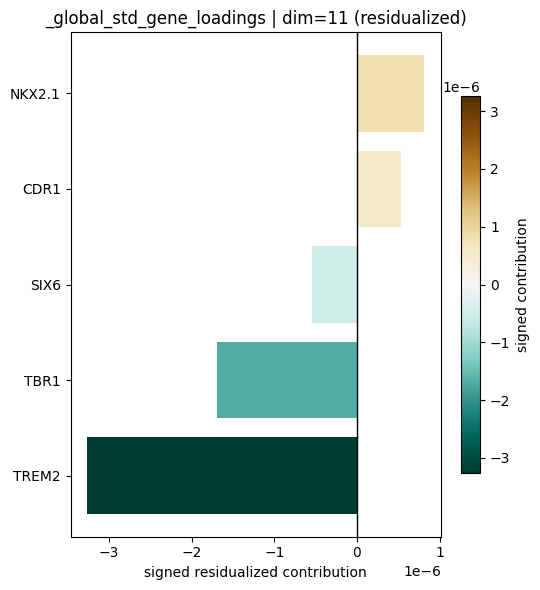

<Axes: title={'center': '_global_std_gene_loadings | dim=11 (residualized)'}, xlabel='signed residualized contribution'>

In [43]:
# Signed bar plot for a single dimension

pl_gene_signed_contribution_bar(
    ctrl_test,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    dim=11,
    n_top=5,
    score_mode="residualized",
)

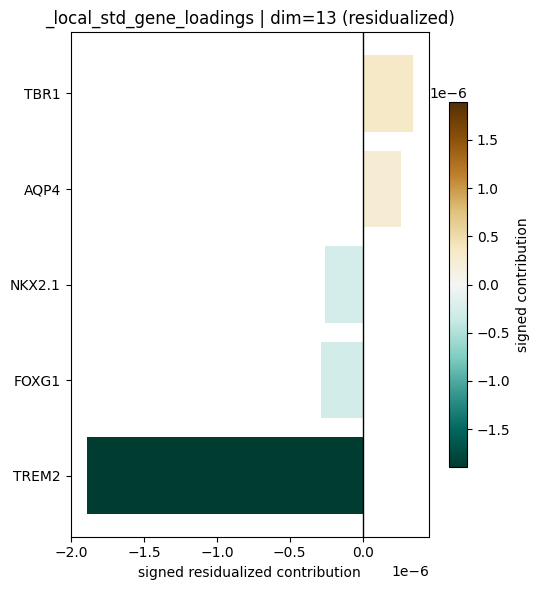

<Axes: title={'center': '_local_std_gene_loadings | dim=13 (residualized)'}, xlabel='signed residualized contribution'>

In [44]:
# Signed bar plot for a single dimension

pl_gene_signed_contribution_bar(
    ctrl_test,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    dim=13,
    n_top=5,
    score_mode="residualized",
)

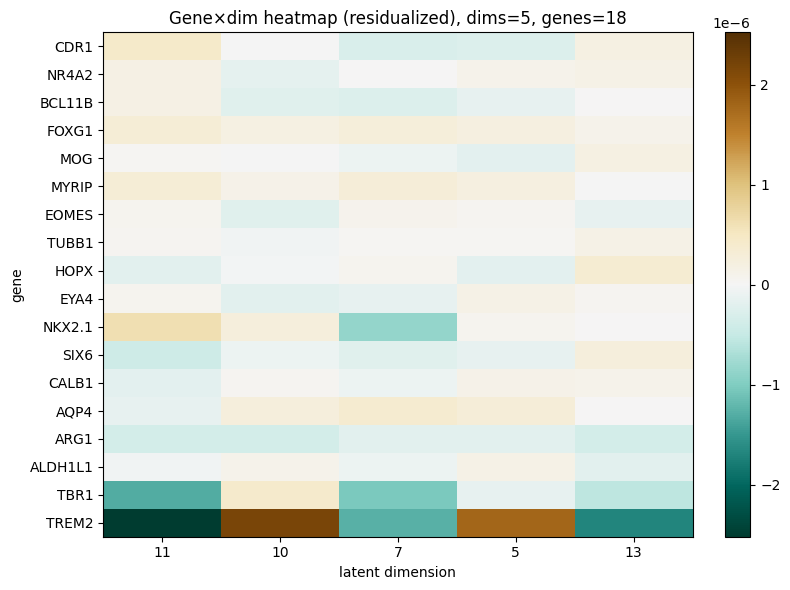

<Axes: title={'center': 'Gene×dim heatmap (residualized), dims=5, genes=18'}, xlabel='latent dimension', ylabel='gene'>

In [44]:
pl_gene_dim_heatmap(
    ctrl_test,
    s_key="_global_std_gene_loadings",
    z_key="_global_emb",
    dims=[11, 10, 7, 5, 13],
    gene_score_mode="residualized",
    n_top_genes_per_dim=10,
    cluster_genes=True,     # optional lightweight clustering for rows
    figsize=(8, 6),
    cmap="BrBG_r",
)

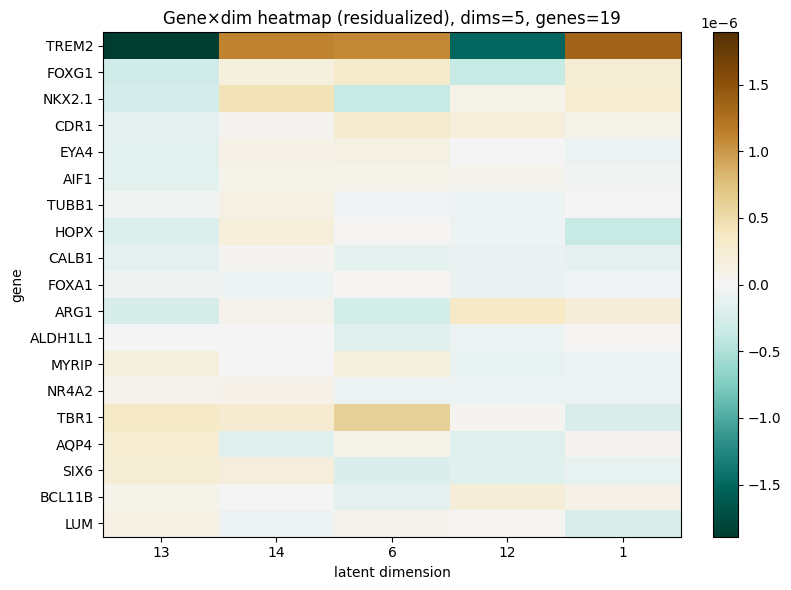

<Axes: title={'center': 'Gene×dim heatmap (residualized), dims=5, genes=19'}, xlabel='latent dimension', ylabel='gene'>

In [45]:
pl_gene_dim_heatmap(
    ctrl_test,
    s_key="_local_std_gene_loadings",
    z_key="_local_emb",
    dims=[13,14,6,12,1],
    gene_score_mode="residualized",
    n_top_genes_per_dim=10,
    cluster_genes=True,     # optional lightweight clustering for rows
    figsize=(8, 6),
    cmap="BrBG_r",
)

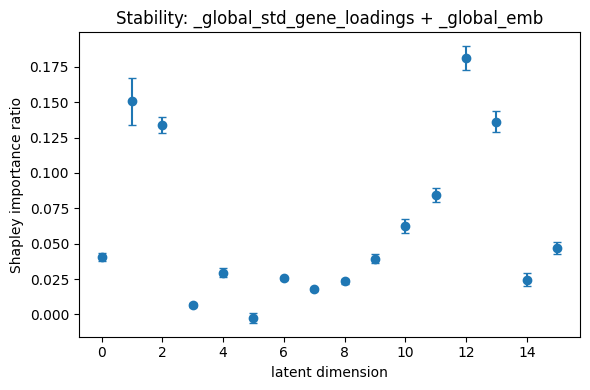

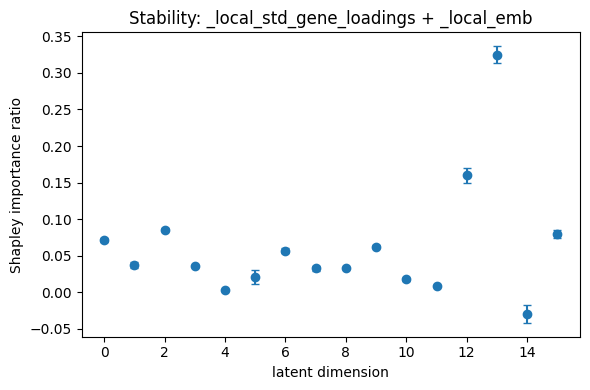

<Axes: title={'center': 'Stability: _local_std_gene_loadings + _local_emb'}, xlabel='latent dimension', ylabel='Shapley importance ratio'>

In [42]:
# Stability plot

pl_dim_importance_stability(ctrl_test, s_key="_global_std_gene_loadings", z_key="_global_emb")
pl_dim_importance_stability(ctrl_test, s_key="_local_std_gene_loadings", z_key="_local_emb")

In [43]:
result.layers['_y_pred_local'].shape,result.layers['_y_pred_local'].shape

((43114, 88), (43114, 88))

In [51]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_local_std_gene_loadings', '_global_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred_local', '_y_pred_global'

In [50]:
result.varm['_global_emb']

array([[-0.70721793, -0.1968358 , -0.34024888, ...,  0.8220406 ,
        -0.3165836 ,  0.87908804],
       [-0.7490616 , -0.79133326,  0.4387249 , ...,  0.671359  ,
        -0.269048  ,  1.0181968 ],
       [-0.2439308 , -0.78707135, -0.2126725 , ...,  1.0608681 ,
        -0.15605906,  1.3287858 ],
       ...,
       [-0.37560332,  0.8631359 ,  0.18100189, ...,  1.1580349 ,
         0.4364654 ,  1.1075069 ],
       [ 0.00491158, -0.45457852,  0.4012726 , ...,  0.29251796,
        -0.3950465 ,  1.7324355 ],
       [-0.9483232 , -0.46048898,  0.5105693 , ...,  0.57588464,
         1.2468807 ,  1.9587524 ]], dtype=float32)

### Gene rank analysis

In [47]:
ctrl_test.layers['_y_pred_local']

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

Top 5 genes for _y_pred_local model:
          gene  r2  r2_log  r2_rank
0  AC129492.1 NaN     NaN      NaN
1        AGO2 NaN     NaN      NaN
2        AIF1 NaN     NaN      NaN
3     ALDH1L1 NaN     NaN      NaN
4        AQP4 NaN     NaN      NaN


/ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/src/InterScale/evaluation/gene_rank_analysis.py:42: RuntimeWarning: invalid value encountered in log1p
  r2_scores_log = [np.log1p(r2) if not np.isnan(r2) else np.nan for r2 in r2_scores]


Top 5 genes for _y_pred_global model:
       gene        r2    r2_log  r2_rank
53  NKX2.1  0.000000  0.000000     86.5
74    SIX6  0.000000  0.000000     86.5
86   FOXG1  0.000000  0.000000     86.5
87   TREM2  0.000000  0.000000     86.5
22     FOS -0.010319 -0.010373     84.0


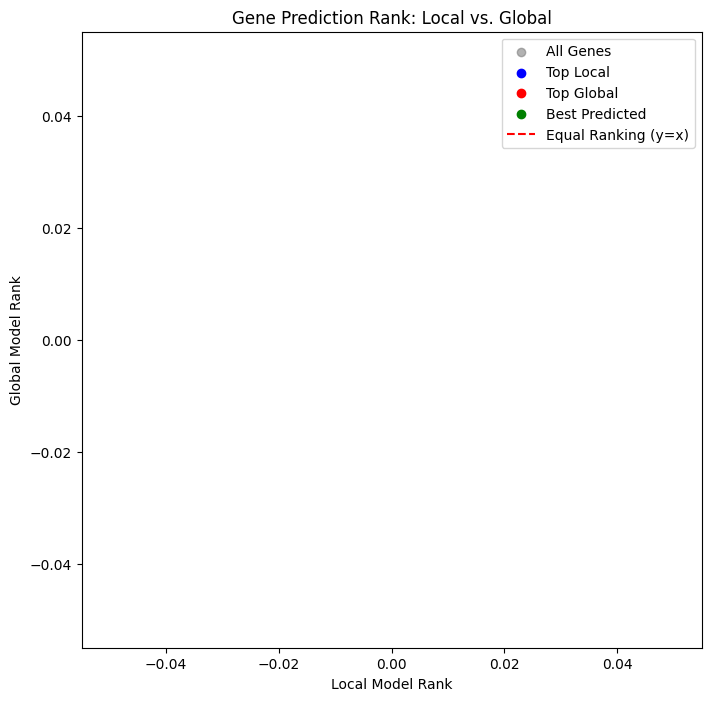

(         gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 0  AC129492.1         NaN         53.0              NaN       NaN
 1        AGO2         NaN         21.0              NaN       NaN
 2        AIF1         NaN          3.0              NaN       NaN
 3     ALDH1L1         NaN         12.0              NaN       NaN
 4        AQP4         NaN         28.0              NaN       NaN,
          gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 0  AC129492.1         NaN         53.0              NaN       NaN
 1        AGO2         NaN         21.0              NaN       NaN
 2        AIF1         NaN          3.0              NaN       NaN
 3     ALDH1L1         NaN         12.0              NaN       NaN
 4        AQP4         NaN         28.0              NaN       NaN,
          gene  Local Rank  Global Rank  Rank Difference  Avg Rank
 0  AC129492.1         NaN         53.0              NaN       NaN
 1        AGO2         NaN         21.0              NaN    

In [45]:
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
gene_rank_analysis(ctrl_test,#result[result.obs['condition'] =='Ctrl'],
                   layers_local_pred = '_y_pred_local',
                   layers_global_pred = '_y_pred_global',
                   top_n = 5,
                   plot_result = True,
                   return_top_genes = True)

### Cluster by distance 

In [48]:
gene_name = 'SHH'
threshold = 50 # can depend on the slide? 

if gene_name in ctrl_test.var_names:
    gene_expression = ctrl_test[:, gene_name].X
    if not isinstance(gene_expression, np.ndarray):
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    else:
        gene_expression = gene_expression.flatten()

    # Annotate cells in the obs field based on the expression threshold
    ctrl_test.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
else:
    print(f"Gene '{gene_name}' not found in adata.var_names.")


In [49]:
import squidpy as sq

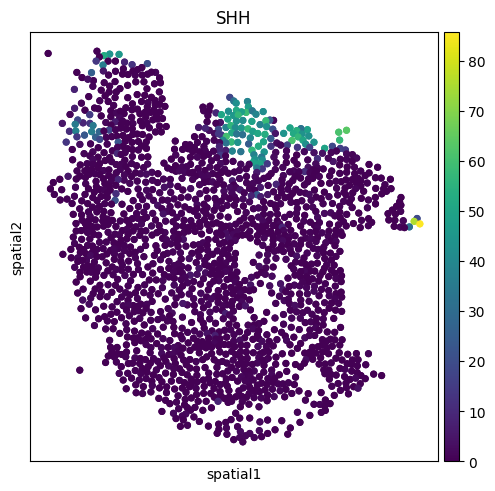

In [50]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH'],
                      cmap = 'viridis',
                      shape= None
                     )

In [49]:
# Coordinates
coords = ctrl_test.obsm["spatial"]
shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
ctrl_test.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs


/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [54]:
dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

n_bins = 5
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

ctrl_test.obs["SHH_dist_ring"] = cats

In [62]:
ctrl_test.uns['SHH_dist_ring_colors'] = ['#556FA7','#C62A22','#7A81FF','#679B36','#E38236']

/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


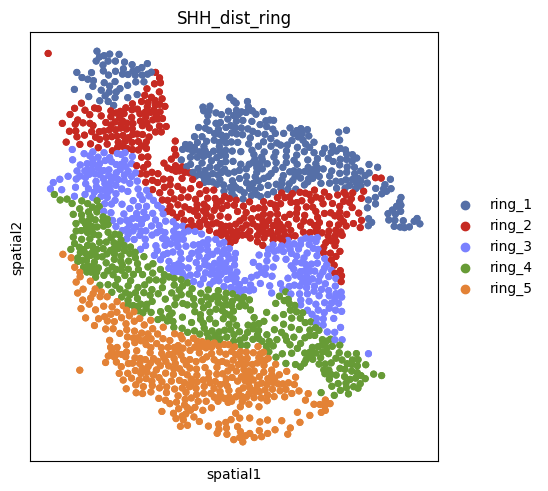

In [63]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH_dist_ring'],
                      cmap = 'viridis_r',
                      shape= None
                     )

/tmp/ipykernel_1625885/2559851921.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  M = (df.groupby("ring")[cols]


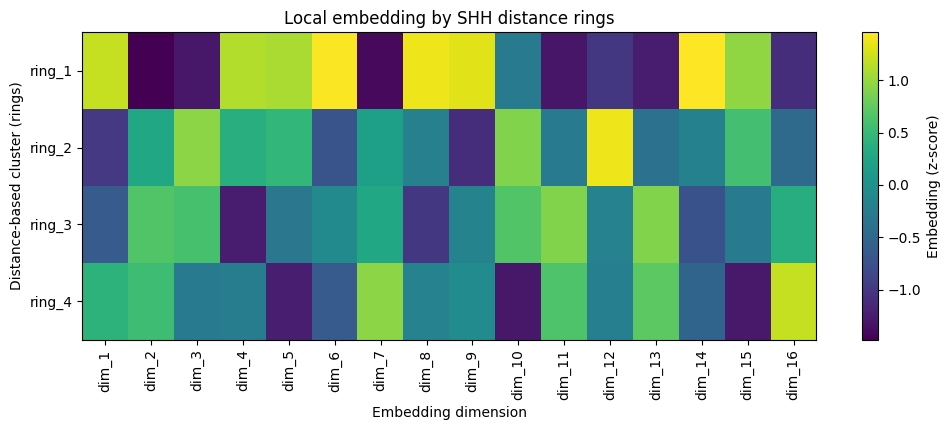

In [52]:
rings = ctrl_test.obs["SHH_dist_ring"].astype("category")
emb = ctrl_test.obsm["_local_emb"]  # shape: (n_cells, d)
d = emb.shape[1]

# --- make a DataFrame for easy grouping
cols = [f"dim_{i+1}" for i in range(d)]
df = pd.DataFrame(emb, columns=cols)
df["ring"] = rings.values

# ensure ordered rows by categorical order
ordered_rings = list(rings.cat.categories)

# --- aggregate: mean per ring (you can swap to .median() if you prefer)
M = (df.groupby("ring")[cols]
       .mean()
       .reindex(ordered_rings))

# --- optional: z-score each column so colors are comparable across dims
# comment this block if you prefer raw means
M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
M = M.fillna(0.0)

# --- plot with matplotlib
fig_h = 0.6 * len(ordered_rings) + 2
fig_w = min(0.45 * d + 3, 18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M.values, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Embedding (z-score)")

# ticks/labels
ax.set_yticks(range(len(ordered_rings)))
ax.set_yticklabels(ordered_rings)

# For many dims, thin x tick labels
step = 1 if d <= 30 else (2 if d <= 60 else 5)
ax.set_xticks(range(0, d, step))
ax.set_xticklabels([cols[i] for i in range(0, d, step)], rotation=90)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Distance-based cluster (rings)")
ax.set_title("Local embedding by SHH distance rings")

plt.tight_layout()
plt.show()